In [1]:
from sklearn.cluster import MeanShift,estimate_bandwidth
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
cluster_center=[(5,5),(3,3),(1,1)]
num_classes=len(cluster_center)
x,y=make_blobs(n_samples=1000,centers=cluster_center,n_features=num_classes,cluster_std=0.3)
np.save("./cluster.npy",x)
x=np.load("./cluster.npy")

#save as Desktop/...

In [3]:
x

array([[3.18572984, 2.67085957],
       [3.20921693, 3.34209408],
       [5.45029935, 4.57828314],
       ...,
       [1.32536273, 1.28377556],
       [4.48112   , 5.26201942],
       [3.10442363, 3.26876054]])

In [4]:
bd=estimate_bandwidth(x,n_samples=1000)
bd

0.8678527893063677

In [5]:
meanshift=MeanShift(bandwidth=bd)
meanshift.fit(x)

MeanShift(bandwidth=0.8678527893063677)

In [6]:
label=meanshift.labels_
set(label)

{0, 1, 2}

In [7]:
center=meanshift.cluster_centers_
center

array([[4.99438234, 4.99202922],
       [3.00184529, 3.0264941 ],
       [1.01114344, 1.01537932]])

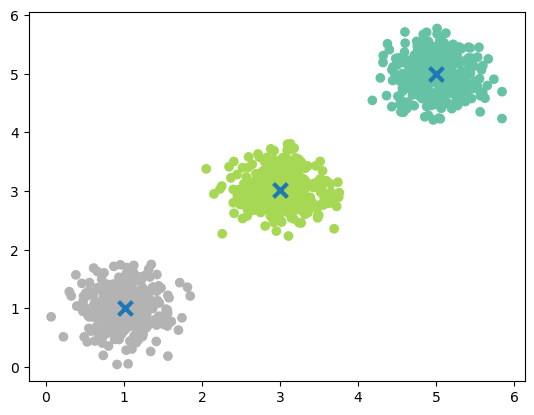

In [8]:
plt.scatter(x[:,0],x[:,1],c=meanshift.labels_,cmap="Set2",marker="o")
plt.scatter(meanshift.cluster_centers_[:,0],meanshift.cluster_centers_[:,1],marker="x",s=100,linewidth=3)
plt.show()